In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
time = []
voltage = []
with open('data.txt') as f:
    lines = f.readlines()
    for line in lines:
        t, v = map(float, line.split())
        time.append(t)
        voltage.append(v)

time = np.array(time)
voltage = np.array(voltage)

In [25]:
DISCH_START = 170


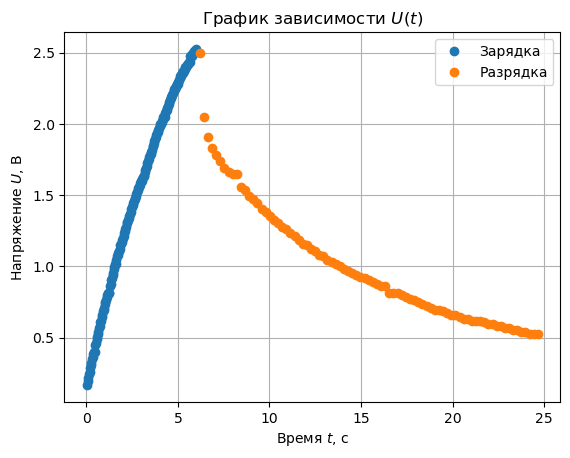

In [30]:
plt.plot(time[:DISCH_START], voltage[:DISCH_START], 'o', label='Зарядка')
plt.plot(time[DISCH_START:], voltage[DISCH_START:], 'o', label='Разрядка')
plt.grid()
plt.title("График зависимости $U(t)$")
plt.xlabel("Время $t$, с")
plt.ylabel("Напряжение $U$, В")
plt.legend()

In [34]:
def mnk(x:np.array, y:np.array):
    mx  = np.mean(x)
    my  = np.mean(y)
    mxy = np.mean(x*y)
    
    mxx = np.mean(x*x)
    myy = np.mean(y*y)

    k = (mxy - mx*my) / (mxx - mx*mx)
    b = my - k*mx

    n = x.size
    
    dk = 1/n**0.5 * np.sqrt((myy - my*my) / (mxx - mx*mx) - k*k)
    db = dk * np.sqrt(mxx - mx*mx)

    return (k, b, dk, db)

-0.06435873342428569


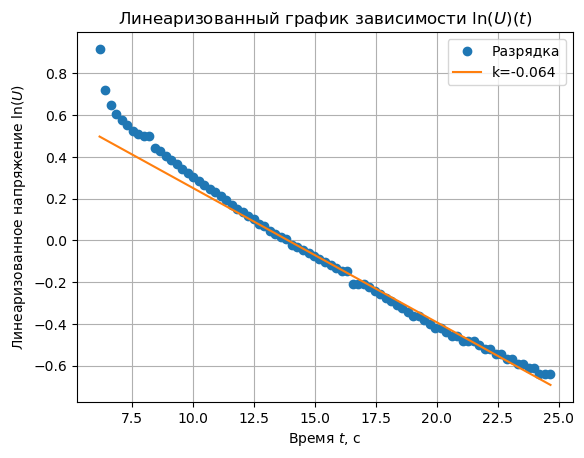

In [ ]:
disch_time = time[DISCH_START:]
disch_voltage = np.log(voltage[DISCH_START:])

k,b, _, _ = mnk(disch_time[20:], disch_voltage[20:])
print(k)

plt.plot(disch_time, disch_voltage, 'o', label='Разрядка')
plt.plot(disch_time, disch_time * k + b, label=f'k={k:.3f}с$^{-1}$')
plt.grid()
plt.title("Линеаризованный график зависимости $\\ln(U)(t)$")
plt.xlabel("Время $t$, с")
plt.ylabel("Линеаризованное напряжение $\\ln(U)$")
plt.legend()
plt.show()